# RFP RAG 프로젝트 EDA

이 노트북은 `data_list.csv`와 원본 RFP 문서 메타데이터를 바탕으로,
공공입찰 제안요청서(RFP) 데이터의 구조를 이해하고 **RAG 시스템 설계 근거**를 확보하기 위한 탐색적 데이터 분석(EDA)을 수행합니다.

## 분석 목표

1. 메타데이터 품질과 결측/이상치를 파악한다.
2. 문서 길이와 구조를 분석해 **chunk size / overlap 설계 후보**를 도출한다.
3. 발주 기관, 사업 분야, 예산, 문서 길이 사이의 관계를 파악해 **메타데이터 필터링 전략**을 설계한다.
4. 텍스트 키워드와 군집 구조를 분석해 **retrieval routing / 요약 축 설계**의 단서를 얻는다.

## 참고

- 원본 CSV에는 `사업 분야` 컬럼이 없으므로, 이 노트북에서는 `사업명 + 사업 요약`을 기반으로 **휴리스틱 사업 분야**를 파생 생성합니다.
- 일부 문서는 텍스트 추출 길이가 매우 짧을 수 있으므로, 후속 단계에서 **재파싱 우선순위 문서**를 식별하는 목적도 포함합니다.


In [2]:
!pip install plotly pandas numpy matplotlib seaborn scikit-learn scipy

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.9 MB 13.0 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.9 MB 13.0 MB/s eta 0:00:01
   ------------------------------ --------- 7.6/9.9 MB 13.0 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 12.6 MB/s  0:00:00

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- -------------

In [3]:
# ============================================================
# 0. 환경 설정 및 라이브러리 로드
# ============================================================
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

# ------------------------
# 한글 폰트 깨짐 방지
# ------------------------
plt.rc("font", family="Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="Malgun Gothic")

pio.templates.default = "plotly_white"
px.defaults.template = "plotly_white"
px.defaults.color_discrete_sequence = px.colors.qualitative.Set2


## 1. 데이터 로딩 및 파생 변수 생성

이 단계에서는 분석에 필요한 최소 전처리를 수행합니다.

### RAG 설계 관점 인사이트

- `발주 기관`, `사업명`, `공개 일자`, `예산`, `파일형식`은 **metadata filter** 후보입니다.
- `텍스트 길이`, `섹션 수`, `사업 분야`는 **chunking / retrieval routing / 평가셋 층화 샘플링**에 직접 연결됩니다.
- `기관명 정규화`, `사업명 유사도`는 사용자가 애매하게 입력한 질의를 보정하는 데 유용합니다.


In [4]:
# ============================================================
# 1. 데이터 로딩 및 파생 변수 생성
# ============================================================
DATA_PATH = Path("data_list.csv")
RAW_DIR = Path("files") / "files"

def load_csv_with_fallback(path: Path) -> pd.DataFrame:
    encodings = ["utf-8-sig", "utf-8", "cp949", "euc-kr"]
    last_error = None
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception as e:
            last_error = e
    raise last_error

df = load_csv_with_fallback(DATA_PATH)
df.columns = [str(c).strip() for c in df.columns]

df["텍스트"] = df["텍스트"].fillna("").astype(str)
df["사업 요약"] = df["사업 요약"].fillna("").astype(str)
df["사업명"] = df["사업명"].fillna("").astype(str)
df["발주 기관"] = df["발주 기관"].fillna("").astype(str)
df["파일형식"] = df["파일형식"].fillna("").astype(str).str.lower()
df["파일명"] = df["파일명"].fillna("").astype(str)

date_cols = ["공개 일자", "입찰 참여 시작일", "입찰 참여 마감일"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df["사업 금액"] = pd.to_numeric(df["사업 금액"], errors="coerce")
df["정제텍스트"] = (
    df["텍스트"]
    .str.replace(r"\s+", " ", regex=True)
    .str.replace("\u3000", " ", regex=False)
    .str.strip()
)

def simple_tokenize(text: str):
    return re.findall(r"[가-힣A-Za-z0-9]+", str(text))

def normalize_org_name(text: str) -> str:
    text = str(text)
    text = re.sub(r"\(주\)|㈜|주식회사|재단법인|사단법인|산학협력단|전자조달|입찰공고", "", text)
    text = re.sub(r"[^가-힣A-Za-z0-9]", "", text)
    return text.strip().lower()

FIELD_KEYWORDS = {
    "교육/학사/LMS": ["학사", "교육", "이러닝", "lms", "학습", "학생", "교과", "비교과", "공유대학", "포털"],
    "교통/ITS/BIS": ["교통", "버스", "철도", "its", "bis", "공항", "운행", "예약발매", "지도정보"],
    "재난/안전/보안": ["재난", "안전", "보안", "응급", "경보", "상황관리", "영상감시", "사이버범죄", "디지털트윈"],
    "의료/보건/복지": ["의료", "병원", "보건", "응급의료", "보험", "사회서비스", "아이돌봄", "장애인", "한의학"],
    "문화/관광/체육": ["문화", "관광", "영화제", "박물관", "민속", "체육", "예술", "스포츠", "대회"],
    "행정/공공정보화": ["행정", "위원회", "전자조달", "기록관리", "행정정보", "공시", "정보화전략", "isp", "정책", "아카이브"],
    "산업/연구/제조": ["연구", "연구원", "산업", "제조", "로봇", "반도체", "고압가스", "의료기기", "수자원", "관개", "실험", "연구비"],
    "경영/ERP/그룹웨어": ["erp", "그룹웨어", "인사", "경영", "회계", "업무시스템", "경영정보"],
    "플랫폼/포털/홈페이지": ["플랫폼", "홈페이지", "포털", "웹", "온라인서비스", "상담시스템", "채팅", "정보시스템"],
}

def infer_business_field(title: str, summary: str, org: str) -> str:
    text = f"{title} {summary} {org}".lower()
    score = {}
    for field, keywords in FIELD_KEYWORDS.items():
        score[field] = sum(1 for kw in keywords if kw.lower() in text)
    best_field = max(score, key=score.get)
    if score[best_field] == 0:
        return "기타/복합"
    return best_field

df["사업 분야"] = df.apply(
    lambda row: infer_business_field(row["사업명"], row["사업 요약"], row["발주 기관"]),
    axis=1,
)
df["발주기관_정규화"] = df["발주 기관"].apply(normalize_org_name)
df["공개연도"] = df["공개 일자"].dt.year
df["공개월"] = df["공개 일자"].dt.month
df["char_count"] = df["정제텍스트"].str.len()
df["word_count"] = df["정제텍스트"].apply(lambda x: len(simple_tokenize(x)))
df["line_count"] = df["텍스트"].apply(lambda x: len([line for line in str(x).splitlines() if line.strip()]))
df["sentence_count"] = df["정제텍스트"].apply(lambda x: len(re.findall(r"[.!?]|다\.|요\.", x)))
df["summary_char_count"] = df["사업 요약"].str.len()
df["budget_log10"] = np.log10(df["사업 금액"].replace(0, np.nan))

df["예산 구간"] = pd.cut(
    df["사업 금액"],
    bins=[-1, 1e8, 3e8, 1e9, 3e9, np.inf],
    labels=["1억 이하", "1~3억", "3~10억", "10~30억", "30억 초과"],
)

display(Markdown(f'''
### 데이터 로딩 결과

- 행 수: **{df.shape[0]:,}건**
- 열 수: **{df.shape[1]:,}개**
- 파일형식 분포: **{', '.join([f'{k} {v}건' for k, v in df['파일형식'].value_counts().to_dict().items()])}**
- 발주 기관 수: **{df['발주 기관'].nunique():,}개**
- 휴리스틱 사업 분야 수: **{df['사업 분야'].nunique():,}개**
'''))

display(df.head(3))



### 데이터 로딩 결과

- 행 수: **100건**
- 열 수: **24개**
- 파일형식 분포: **hwp 96건, pdf 4건**
- 발주 기관 수: **87개**
- 휴리스틱 사업 분야 수: **10개**


,공고 번호,공고 차수,사업명,사업 금액,발주 기관,공개 일자,입찰 참여 시작일,입찰 참여 마감일,사업 요약,파일형식,파일명,텍스트,정제텍스트,사업 분야,발주기관_정규화,공개연도,공개월,char_count,word_count,line_count,sentence_count,summary_char_count,budget_log10,예산 구간
0,20241001798,0.0,한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보시스템 고도화,130000000.0,한영대학,2024-10-04 13:51:23,NaT,2024-10-15 17:00:00,- 한영대학교 특성화 맞춤형 교육환경 구축을 위해 트랙운영 학사정보시스템을 고도화한다.\n- 트랙제도를 도입하여 다양한 진로 선택 기회를 제공하고 산업현장의 경쟁력을 강화한다.\n- 효과적인 교육과정 지원 및...,hwp,한영대학_한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보.hwp,\n \n2024년 특성화 맞춤형 교육환경 구축 – 트랙운영 학사정보시스템 고도화\n 제안요청서\n\n2024. 10.\n \n \n \n목 차\nⅠ. 사업 안내 - ...,2024년 특성화 맞춤형 교육환경 구축 – 트랙운영 학사정보시스템 고도화 제안요청서 2024. 10. 목 차 Ⅰ. 사업 안내 - 1 1. 사업개요 - 1 2. 추진배경 및 필요성 - 1 3. 기대효과 - 1 ...,교육/학사/LMS,한영대학,2024,10,1223,304,82,24,238,8.113943,1~3억
1,20241002912,0.0,2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선,129300000.0,한국연구재단,2024-10-04 15:01:52,2024-10-14 10:00:00,2024-10-16 14:00:00,- 사업 개요: 2024년 대학 산학협력활동 실태조사 시스템(UICC) 기능개선\n- 추진배경: 대학 산학협력활동 실태조사를 안정적으로 운영하고 사용자 편의성을 개선하기 위해 필요\n- 사업범위: UICC 시...,hwp,한국연구재단_2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선.hwp,\r\n \r\n \r\n \r\n제 안 요 청 서\r\n[ 2024년 대학 산학협력활동 실태조사 시스템(UICC) 기능개선 ]\r\n2024. 10.\r\n \r\n담 당\r\n부 서 명\r\n성...,제 안 요 청 서 [ 2024년 대학 산학협력활동 실태조사 시스템(UICC) 기능개선 ] 2024. 10. 담 당 부 서 명 성 명 전 화 사업관련 학술데이터분석팀 한민아 042-869-6672 계약관련 운영...,행정/공공정보화,한국연구재단,2024,10,2398,571,149,20,273,8.111599,1~3억
2,20240827859,0.0,EIP3.0 고압가스 안전관리 시스템 구축 용역,40000000.0,한국생산기술연구원,2024-08-28 11:31:02,2024-08-29 09:00:00,2024-09-09 10:00:00,"- 사업 개요: EIP3.0 고압가스 안전관리 시스템 구축 용역\n- 추진배경: 안전사고 증가, 법적 요구사항, 연구 환경 보호에 대한 필요성\n- 사업범위: 화학물질 운영현황 통계 정보 제공, 고압가스 화학...",hwp,한국생산기술연구원_EIP3.0 고압가스 안전관리 시스템 구축 용역.hwp,\r\n \r\nEIP3.0 고압가스 안전관리\r\n시스템 구축 용역\r\n2024. 08.\r\n \r\n디지털행정추진실\r\n한국생산기술연구원\r\n \r\n담당\r\n사양 및 과업\r\n디지...,EIP3.0 고압가스 안전관리 시스템 구축 용역 2024. 08. 디지털행정추진실 한국생산기술연구원 담당 사양 및 과업 디지털행정추진실 전재우 TEL: 041-589-8095 FAX : 041-589-8095...,산업/연구/제조,한국생산기술연구원,2024,8,182,42,22,4,231,7.602060,1억 이하


## 2. 기본 메타데이터 탐색 (Basic Metadata Overview)

### 이 단계에서 확인할 것

- 어떤 컬럼이 비어 있는가?
- 발주 기관과 사업 분야가 얼마나 편중되어 있는가?
- 예산은 어떤 분포를 가지며, 극단값은 어느 정도인가?

### RAG 설계 관점 인사이트

- 결측이 많은 메타데이터는 hard filter보다는 **soft reranking feature**로 쓰는 편이 안전합니다.
- 발주 기관 편중도가 낮으면 기관명 자체가 좋은 metadata filter가 되지만, 유사명/변형명 정규화가 필요합니다.
- 예산은 질의 조건("몇 억 이상 사업")이나 문서 비교 시 유용하지만, 분포가 심하게 왜곡되면 **log scale**로 다루는 것이 적절합니다.


,missing_count,missing_ratio
입찰 참여 시작일,26,26.0
공고 번호,18,18.0
공고 차수,18,18.0
입찰 참여 마감일,8,8.0
budget_log10,7,7.0
사업 금액,1,1.0
예산 구간,1,1.0
사업명,0,0.0
발주 기관,0,0.0
공개 일자,0,0.0


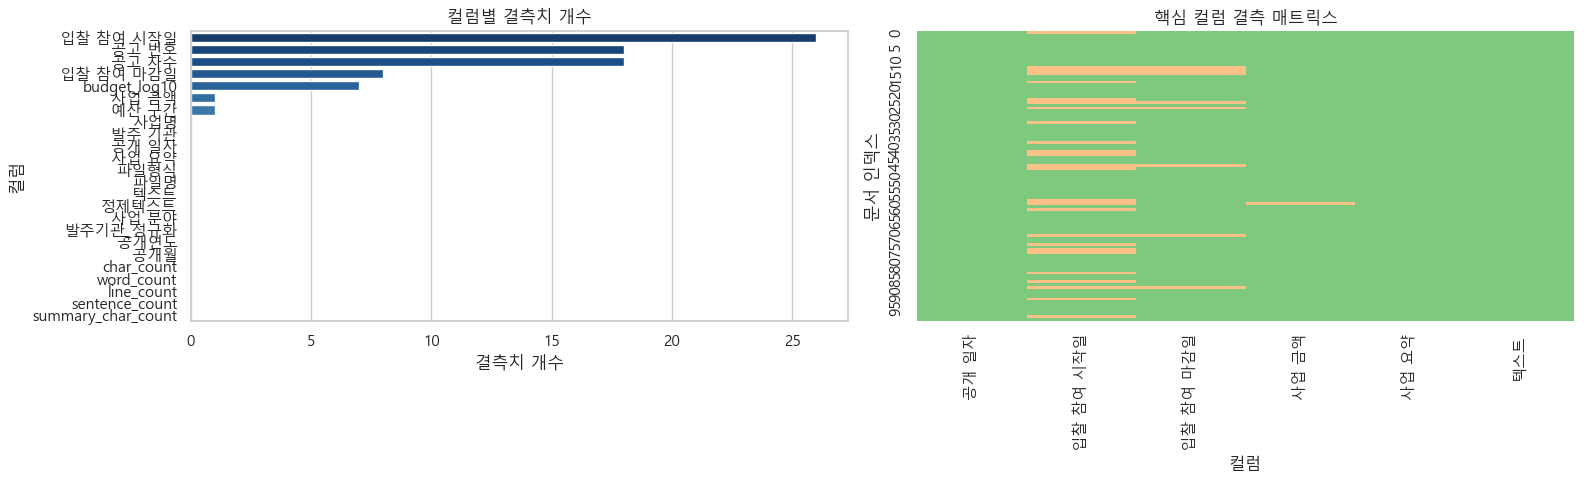


**해석 가이드**

- `입찰 참여 시작일`, `입찰 참여 마감일` 결측은 꽤 자연스러운 공고 속성이므로 삭제보다는 **nullable metadata**로 유지하는 편이 좋습니다.
- `사업 금액`이 0 또는 결측인 문서는 비교·필터링에서는 예외 처리 대상입니다.
- `텍스트`가 비어 있지 않더라도 길이가 지나치게 짧은 문서는 별도로 재점검해야 합니다.


In [5]:
# ============================================================
# 2-1. 결측치 개요
# ============================================================
missing_df = (
    df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_ratio=lambda x: (x["missing_count"] / len(df) * 100).round(2))
    .sort_values(["missing_count", "missing_ratio"], ascending=False)
)

display(missing_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    data=missing_df.reset_index().rename(columns={"index": "column"}),
    x="missing_count",
    y="column",
    ax=axes[0],
    palette="Blues_r",
)
axes[0].set_title("컬럼별 결측치 개수")
axes[0].set_xlabel("결측치 개수")
axes[0].set_ylabel("컬럼")

sns.heatmap(
    df[["공개 일자", "입찰 참여 시작일", "입찰 참여 마감일", "사업 금액", "사업 요약", "텍스트"]].isna(),
    cbar=False,
    ax=axes[1],
    cmap=["#7fc97f", "#fdc086"],
)
axes[1].set_title("핵심 컬럼 결측 매트릭스")
axes[1].set_xlabel("컬럼")
axes[1].set_ylabel("문서 인덱스")

plt.tight_layout()
plt.show()

display(Markdown('''
**해석 가이드**

- `입찰 참여 시작일`, `입찰 참여 마감일` 결측은 꽤 자연스러운 공고 속성이므로 삭제보다는 **nullable metadata**로 유지하는 편이 좋습니다.
- `사업 금액`이 0 또는 결측인 문서는 비교·필터링에서는 예외 처리 대상입니다.
- `텍스트`가 비어 있지 않더라도 길이가 지나치게 짧은 문서는 별도로 재점검해야 합니다.
'''))


In [6]:
# ============================================================
# 2-2. 발주 기관 / 사업 분야 / 파일형식 분포
# ============================================================
top_orgs = df["발주 기관"].value_counts().head(15).reset_index()
top_orgs.columns = ["발주 기관", "건수"]

fig = px.bar(
    top_orgs,
    x="건수",
    y="발주 기관",
    orientation="h",
    title="발주 기관별 공고 수 Top 15",
    text="건수",
)
fig.update_layout(height=520, yaxis=dict(categoryorder="total ascending"))
fig.show()

field_counts = df["사업 분야"].value_counts().reset_index()
field_counts.columns = ["사업 분야", "건수"]

fig = px.bar(
    field_counts,
    x="사업 분야",
    y="건수",
    title="휴리스틱 사업 분야 분포",
    text="건수",
)
fig.update_layout(height=500, xaxis_tickangle=-30)
fig.show()

format_counts = df["파일형식"].value_counts().reset_index()
format_counts.columns = ["파일형식", "건수"]

fig = px.pie(
    format_counts,
    names="파일형식",
    values="건수",
    title="파일형식 분포",
)
fig.show()

display(Markdown('''
**RAG 시사점**

- 특정 기관이 많이 반복되면 기관명 필터가 검색 효율을 높일 수 있지만, 현재 데이터는 기관이 비교적 넓게 퍼져 있어 **기관명 + 사업 분야 + 키워드**의 복합 필터가 더 유리할 가능성이 큽니다.
- 파일형식이 HWP 중심이므로, 추후 원문 재처리가 필요할 때는 PDF보다 **HWP 파싱 신뢰도 확보**가 더 중요합니다.
- 사업 분야 분포는 질문셋 설계 시 **층화 샘플링(stratified sampling)** 기준으로 활용할 수 있습니다.
'''))



**RAG 시사점**

- 특정 기관이 많이 반복되면 기관명 필터가 검색 효율을 높일 수 있지만, 현재 데이터는 기관이 비교적 넓게 퍼져 있어 **기관명 + 사업 분야 + 키워드**의 복합 필터가 더 유리할 가능성이 큽니다.
- 파일형식이 HWP 중심이므로, 추후 원문 재처리가 필요할 때는 PDF보다 **HWP 파싱 신뢰도 확보**가 더 중요합니다.
- 사업 분야 분포는 질문셋 설계 시 **층화 샘플링(stratified sampling)** 기준으로 활용할 수 있습니다.


,사업 금액
count,9.900000e+01
mean,6.906720e+08
std,1.966691e+09
min,0.000000e+00
25%,7.000000e+07
50%,1.727000e+08
75%,4.064889e+08
90%,1.018794e+09
95%,2.353511e+09
99%,1.132674e+10


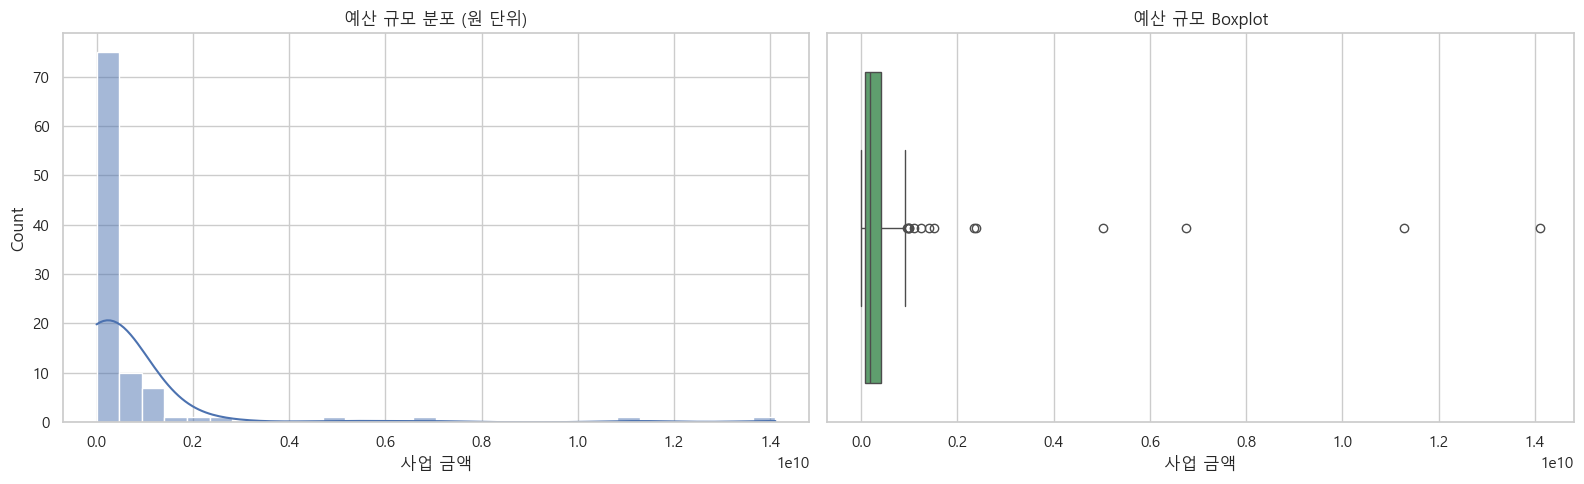


**예산 이상치 기준(IQR)**

- Q1: **70,000,000**
- Q3: **406,488,938**
- Upper bound: **911,222,346**
- 이상치 후보 수: **14건**


,사업명,발주 기관,사업 금액,사업 분야,파일형식
47,[재공고]차세대 통합정보시스템(ERP) 구축,한국가스공사,1.410701e+10,플랫폼/포털/홈페이지,hwp
7,차세대 포털·학사 정보시스템 구축사업,고려대학교,1.127000e+10,교육/학사/LMS,pdf
26,[긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 국회 방송시스템 구축 및 지역의회 연계 개선 PMC 용역,KOICA 전자조달,6.758571e+09,행정/공공정보화,hwp
72,우즈벡-키르기즈스탄 기후변화대응 스마트 관개시스템 구축사업,사단법인아시아물위원회사무국,5.031000e+09,행정/공공정보화,hwp
24,용인 첨단 시스템반도체 국가산단 용수공급사업 타당성조사 및 기본계획 수립 용역,한국수자원공사,2.392940e+09,산업/연구/제조,hwp
99,스마트 팹 서비스 활용체계 구축관련 설비온라인 시스템 구축 용역,나노종합기술원,2.349130e+09,산업/연구/제조,hwp
93,2024년도 GKL 그룹웨어 시스템 구축 용역,그랜드코리아레저(주),1.515000e+09,행정/공공정보화,hwp
69,(긴급)「2024년도 차세대 응급의료 상황관리시스템 구축」 위탁용역,국립중앙의료원,1.400000e+09,재난/안전/보안,hwp
89,(긴급) 모잠비크 마푸토 지능형교통시스템(ITS) 구축사업 사업타당성조사(F/S) 용역,한국수출입은행,1.247000e+09,교통/ITS/BIS,hwp
79,인천공항운영서비스㈜ 차세대 ERP시스템 구축 사업(재공고),인천공항운영서비스(주),1.095992e+09,경영/ERP/그룹웨어,hwp



**RAG 시사점**

- 예산은 규모 차이가 매우 크므로, 질의 응답 시 원값 그대로 비교하기보다 **구간화(예: 1억 이하 / 1~3억 / 3~10억 / 10억 이상)**가 더 실용적입니다.
- 고예산 사업은 문서 길이·요구사항 복잡도와 연결될 수 있으므로, 후속 분석에서 텍스트 길이와 함께 교차 확인합니다.
- 금액 0 또는 극단값은 OCR/파싱 혹은 공고 특성 문제일 수 있어 별도 점검 대상입니다.


In [7]:
# ============================================================
# 2-3. 예산 규모 통계 및 이상치 탐색
# ============================================================
budget_stats = df["사업 금액"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame(name="사업 금액")
display(budget_stats)

q1 = df["사업 금액"].quantile(0.25)
q3 = df["사업 금액"].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
lower_bound = max(0, q1 - 1.5 * iqr)

budget_outliers = df[(df["사업 금액"] > upper_bound) | (df["사업 금액"] < lower_bound)].copy()
budget_outliers = budget_outliers.sort_values("사업 금액", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df["사업 금액"].dropna(), bins=30, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("예산 규모 분포 (원 단위)")
axes[0].set_xlabel("사업 금액")

sns.boxplot(x=df["사업 금액"], ax=axes[1], color="#55A868")
axes[1].set_title("예산 규모 Boxplot")
axes[1].set_xlabel("사업 금액")

plt.tight_layout()
plt.show()

fig = px.histogram(
    df.dropna(subset=["budget_log10"]),
    x="budget_log10",
    nbins=25,
    title="예산 규모 분포 (log10 스케일)",
)
fig.update_xaxes(title="log10(사업 금액)")
fig.show()

display(Markdown(f'''
**예산 이상치 기준(IQR)**

- Q1: **{q1:,.0f}**
- Q3: **{q3:,.0f}**
- Upper bound: **{upper_bound:,.0f}**
- 이상치 후보 수: **{len(budget_outliers)}건**
'''))

display(
    budget_outliers[["사업명", "발주 기관", "사업 금액", "사업 분야", "파일형식"]].head(15)
)

display(Markdown('''
**RAG 시사점**

- 예산은 규모 차이가 매우 크므로, 질의 응답 시 원값 그대로 비교하기보다 **구간화(예: 1억 이하 / 1~3억 / 3~10억 / 10억 이상)**가 더 실용적입니다.
- 고예산 사업은 문서 길이·요구사항 복잡도와 연결될 수 있으므로, 후속 분석에서 텍스트 길이와 함께 교차 확인합니다.
- 금액 0 또는 극단값은 OCR/파싱 혹은 공고 특성 문제일 수 있어 별도 점검 대상입니다.
'''))


## 3. 텍스트 길이 및 구조 분석 (Text Length & Structure Analysis)

이 단계는 **chunking 전략**을 설계하기 위한 핵심 분석입니다.

### 보고자 하는 것

- 문서별 글자 수 / 단어 수 / 줄 수 분포
- 기관/사업 분야별 문서 길이 차이
- 문서 구조가 정형적인지, 섹션 단위 chunking이 가능한지

### RAG 설계 관점 인사이트

- 문서 길이가 매우 다양하면 단일 chunk size보다 **2~3개 후보를 비교 실험**하는 것이 좋습니다.
- 섹션 구조가 반복적이면 페이지/문단보다 **section-aware chunking**이 더 효과적일 수 있습니다.
- 텍스트가 극단적으로 짧은 문서는 retrieval에 노이즈가 될 수 있어 예외 처리 또는 재추출이 필요합니다.


,count,mean,std,min,25%,50%,75%,max
char_count,100.0,3304.47,3348.945052,66.0,939.75,2264.0,5072.75,16434.0
word_count,100.0,780.36,798.674413,14.0,213.00,477.5,1191.75,3979.0
line_count,100.0,176.49,189.896330,4.0,49.75,111.0,245.50,1085.0
sentence_count,100.0,50.82,87.605795,0.0,23.00,40.5,60.25,874.0
summary_char_count,100.0,269.21,73.040503,142.0,220.50,249.5,297.25,524.0


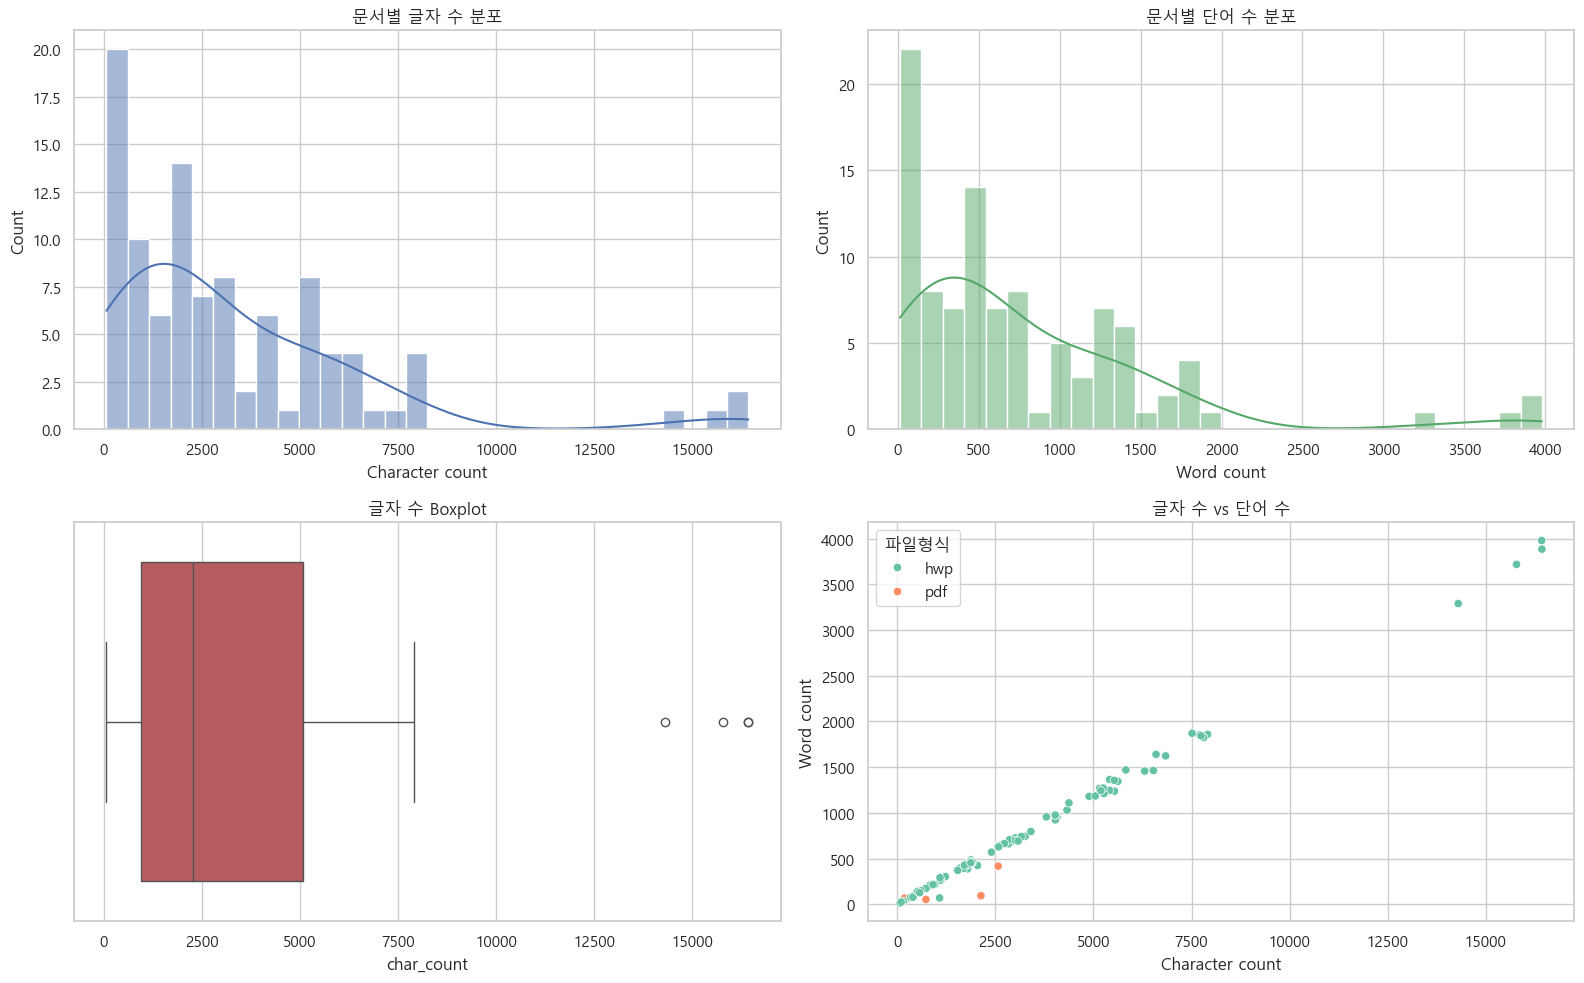

**글자 수 500자 미만 문서 수:** 15건

,사업명,발주 기관,파일명,char_count,파일형식
18,2024년 건설기술에 관한 특허·실용신안 활용실적 관리시스템 개편 용역,한국발명진흥회 입찰공고,한국발명진흥회 입찰공고_2024년 건설기술에 관한 특허·실용신안 활용실.hwp,66,hwp
20,JST 공유대학(원) xAPI기반 LRS시스템 구축,전북대학교,전북대학교_JST 공유대학(원) xAPI기반 LRS시스템 구축.hwp,94,hwp
17,2025 구미아시아육상경기선수권대회 종합정보시스템 및 홈페이지 등 구축 용역,2025 구미 아시아육상경기선수권대회 조직위원회,2025 구미 아시아육상경기선수권대회 조직위원회_2025 구미아시아육상경.hwp,150,hwp
12,[사전공개] 학업성취도 다차원 종단분석 통합시스템 1차 고도화 용역,서울시립대학교,서울시립대학교_[사전공개] 학업성취도 다차원 종단분석 통합시스템 1차.pdf,179,pdf
2,EIP3.0 고압가스 안전관리 시스템 구축 용역,한국생산기술연구원,한국생산기술연구원_EIP3.0 고압가스 안전관리 시스템 구축 용역.hwp,182,hwp
8,스포츠윤리센터 LMS(학습지원시스템) 기능개선,재단법인스포츠윤리센터,재단법인스포츠윤리센터_스포츠윤리센터 LMS(학습지원시스템) 기능개선.hwp,205,hwp
49,사업장 사회보험료 지원 고시 개정에 따른 정보시스템 보완 개발,국민연금공단,국민연금공단_사업장 사회보험료 지원 고시 개정에 따른 정보시스템 보.hwp,340,hwp
86,2024년 벤처확인종합관리시스템 기능 고도화 용역사업 입찰공고,(사)벤처기업협회,(사)벤처기업협회_2024년 벤처확인종합관리시스템 기능 고도화 용역사업 .hwp,398,hwp
78,IP-NAVI 해외지식재산센터 사업관리 시스템 기능개선,한국지식재산보호원,한국지식재산보호원_IP-NAVI 해외지식재산센터 사업관리 시스템 기능개.hwp,411,hwp
53,통합정보시스템 고도화 용역,한국한의학연구원,한국한의학연구원_통합정보시스템 고도화 용역.hwp,421,hwp


In [8]:
# ============================================================
# 3-1. 문서 길이 분포
# ============================================================
length_stats = df[["char_count", "word_count", "line_count", "sentence_count", "summary_char_count"]].describe().T
display(length_stats)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(df["char_count"], bins=30, kde=True, ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("문서별 글자 수 분포")
axes[0, 0].set_xlabel("Character count")

sns.histplot(df["word_count"], bins=30, kde=True, ax=axes[0, 1], color="#55A868")
axes[0, 1].set_title("문서별 단어 수 분포")
axes[0, 1].set_xlabel("Word count")

sns.boxplot(x=df["char_count"], ax=axes[1, 0], color="#C44E52")
axes[1, 0].set_title("글자 수 Boxplot")

sns.scatterplot(data=df, x="char_count", y="word_count", hue="파일형식", ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("글자 수 vs 단어 수")
axes[1, 1].set_xlabel("Character count")
axes[1, 1].set_ylabel("Word count")

plt.tight_layout()
plt.show()

short_docs = df[df["char_count"] < 500].sort_values("char_count")
display(Markdown(f"**글자 수 500자 미만 문서 수:** {len(short_docs)}건"))
display(short_docs[["사업명", "발주 기관", "파일명", "char_count", "파일형식"]])


In [9]:
# ============================================================
# 3-2. 발주 기관 / 사업 분야별 평균 문서 길이 비교
# ============================================================
field_length = (
    df.groupby("사업 분야")[["char_count", "word_count"]]
    .mean()
    .round(1)
    .sort_values("char_count", ascending=False)
    .reset_index()
)
display(field_length)

fig = px.bar(
    field_length,
    x="사업 분야",
    y="char_count",
    title="사업 분야별 평균 문서 글자 수",
    text="char_count",
)
fig.update_layout(height=500, xaxis_tickangle=-30)
fig.show()

top_org_length = (
    df.groupby("발주 기관")["char_count"]
    .agg(["count", "mean"])
    .query("count >= 2")
    .sort_values("mean", ascending=False)
    .head(15)
    .reset_index()
)

if not top_org_length.empty:
    fig = px.bar(
        top_org_length,
        x="mean",
        y="발주 기관",
        orientation="h",
        title="문서가 2건 이상인 발주 기관의 평균 글자 수",
        text="mean",
    )
    fig.update_layout(height=520, yaxis=dict(categoryorder="total ascending"))
    fig.show()

display(Markdown('''
**RAG 시사점**

- 사업 분야별 평균 길이가 다르면, retrieval 성능 비교는 전체 평균만 보지 말고 **분야별로 따로 평가**하는 편이 좋습니다.
- 특정 기관에서 유독 긴 문서가 반복된다면, 그 기관 질의에서는 더 큰 chunk 또는 section-aware split이 유리할 수 있습니다.
- 짧은 문서와 긴 문서를 같은 방식으로 chunking하면, 짧은 문서는 과분할(over-splitting), 긴 문서는 과압축(under-segmentation) 문제가 생길 수 있습니다.
'''))


,사업 분야,char_count,word_count
0,교통/ITS/BIS,5995.2,1421.8
1,산업/연구/제조,4386.1,1019.6
2,재난/안전/보안,4028.6,969.7
3,문화/관광/체육,3368.8,801.6
4,행정/공공정보화,3099.6,725.8
5,의료/보건/복지,2892.5,691.0
6,플랫폼/포털/홈페이지,2781.3,673.1
7,경영/ERP/그룹웨어,2632.7,600.0
8,교육/학사/LMS,2058.3,471.3
9,기타/복합,712.0,170.5



**RAG 시사점**

- 사업 분야별 평균 길이가 다르면, retrieval 성능 비교는 전체 평균만 보지 말고 **분야별로 따로 평가**하는 편이 좋습니다.
- 특정 기관에서 유독 긴 문서가 반복된다면, 그 기관 질의에서는 더 큰 chunk 또는 section-aware split이 유리할 수 있습니다.
- 짧은 문서와 긴 문서를 같은 방식으로 chunking하면, 짧은 문서는 과분할(over-splitting), 긴 문서는 과압축(under-segmentation) 문제가 생길 수 있습니다.


,count,mean,std,min,25%,50%,75%,max
char_count,100.0,3304.470000,3348.945052,66.0,939.75,2264.0,5072.75,16434.000000
section_count,100.0,4.000000,1.348400,0.0,3.75,5.0,5.00,5.000000
mean_section_chars,97.0,762.089175,806.779168,10.0,256.50,551.8,1005.40,5224.666667


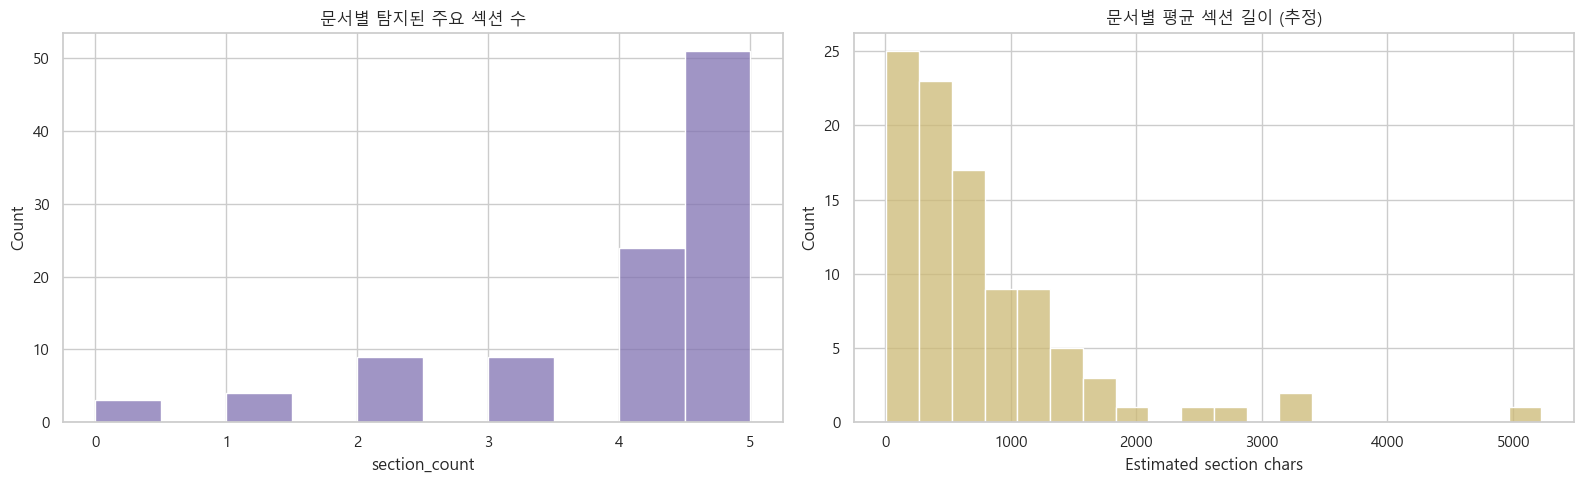

,섹션,section_chars,section_share
0,입찰/계약/평가,879.184783,0.361725
1,사업개요,960.492537,0.252234
2,범위/내용,995.013158,0.250058
3,배경/목적,655.977011,0.199050
4,체계/일정,455.423077,0.134615



**주의**

- 본 섹션 분석은 목차/머리말 노이즈를 일부 완화한 **휴리스틱 추정**입니다.
- 그럼에도 불구하고 주요 섹션의 반복성이 높다면, 향후에는 정규식/레이아웃 기반 **section-aware parser**를 붙일 가치가 있습니다.

**RAG 시사점**

- 평균 섹션 길이가 600~1,500자 수준으로 모이면, page chunk보다 **섹션 경계 기반 청킹**을 실험할 근거가 됩니다.
- 반대로 섹션 탐지가 불안정하면, 초기 baseline은 **fixed-size + overlap**이 더 안전합니다.


In [10]:
# ============================================================
# 3-3. 문서 구조 / 섹션 분석 (휴리스틱)
# ============================================================
SECTION_PATTERNS = {
    "사업개요": [r"사업개요", r"과업의 개요", r"용역개요"],
    "배경/목적": [r"추진배경", r"필요성", r"목적", r"기대효과"],
    "범위/내용": [r"구축범위", r"사업범위", r"과업의 범위", r"사업내용", r"제안요청 내용", r"제안요구 사항"],
    "체계/일정": [r"추진체계", r"수행체계", r"추진일정", r"구축일정", r"일정"],
    "입찰/계약/평가": [r"입찰", r"계약", r"제안안내", r"제안서 작성", r"평가", r"협상", r"제출서류"],
}

def meaningful_match_position(text: str, patterns, early_cutoff: int = 500):
    positions = []
    for p in patterns:
        positions.extend([m.start() for m in re.finditer(p, text)])
    positions = sorted(set(positions))
    if not positions:
        return None
    if len(positions) >= 2 and positions[0] < early_cutoff:
        return positions[1]
    return positions[0]

def estimate_section_spans(text: str):
    positions = {}
    for section, patterns in SECTION_PATTERNS.items():
        pos = meaningful_match_position(text, patterns)
        if pos is not None:
            positions[section] = pos
    if not positions:
        return {}
    ordered = sorted(positions.items(), key=lambda x: x[1])
    spans = {}
    for idx, (section, start) in enumerate(ordered):
        end = ordered[idx + 1][1] if idx + 1 < len(ordered) else len(text)
        spans[section] = max(end - start, 0)
    return spans

section_records = []
section_summary = []

for _, row in df.iterrows():
    text = row["정제텍스트"]
    spans = estimate_section_spans(text)
    section_summary.append(
        {
            "사업명": row["사업명"],
            "발주 기관": row["발주 기관"],
            "char_count": row["char_count"],
            "section_count": len(spans),
            "mean_section_chars": np.mean(list(spans.values())) if spans else np.nan,
        }
    )
    total = sum(spans.values()) if spans else 0
    for section, span in spans.items():
        section_records.append(
            {
                "사업명": row["사업명"],
                "섹션": section,
                "section_chars": span,
                "section_share": span / total if total else np.nan,
            }
        )

section_summary_df = pd.DataFrame(section_summary)
section_records_df = pd.DataFrame(section_records)

display(section_summary_df.describe().T)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(section_summary_df["section_count"].dropna(), bins=10, ax=axes[0], color="#8172B2")
axes[0].set_title("문서별 탐지된 주요 섹션 수")

sns.histplot(section_summary_df["mean_section_chars"].dropna(), bins=20, ax=axes[1], color="#CCB974")
axes[1].set_title("문서별 평균 섹션 길이 (추정)")
axes[1].set_xlabel("Estimated section chars")
plt.tight_layout()
plt.show()

if not section_records_df.empty:
    avg_section_share = (
        section_records_df.groupby("섹션")[["section_chars", "section_share"]]
        .mean()
        .sort_values("section_share", ascending=False)
        .reset_index()
    )
    display(avg_section_share)

    fig = px.bar(
        avg_section_share,
        x="섹션",
        y="section_share",
        title="주요 섹션별 평균 비중 (휴리스틱 추정)",
        text=avg_section_share["section_share"].round(3),
    )
    fig.update_layout(height=450)
    fig.show()

display(Markdown('''
**주의**

- 본 섹션 분석은 목차/머리말 노이즈를 일부 완화한 **휴리스틱 추정**입니다.
- 그럼에도 불구하고 주요 섹션의 반복성이 높다면, 향후에는 정규식/레이아웃 기반 **section-aware parser**를 붙일 가치가 있습니다.

**RAG 시사점**

- 평균 섹션 길이가 600~1,500자 수준으로 모이면, page chunk보다 **섹션 경계 기반 청킹**을 실험할 근거가 됩니다.
- 반대로 섹션 탐지가 불안정하면, 초기 baseline은 **fixed-size + overlap**이 더 안전합니다.
'''))


## 4. 메타데이터 심층 교차 분석 (Deep Cross-Metadata Analysis)

### 이 단계에서 확인할 것

- 기관과 사업 분야가 얼마나 강하게 연결되어 있는가?
- 예산이 문서 길이와 관련이 있는가?
- 기관명/사업명에 얼마나 비슷한 표현이 섞여 있는가?

### RAG 설계 관점 인사이트

- 기관-분야 교차 구조가 뚜렷하면 metadata filter 조합을 통해 search space를 줄일 수 있습니다.
- 예산과 문서 길이가 상관이 높으면 대형 사업일수록 chunking/요약 전략을 별도로 가져갈 수 있습니다.
- 유사 기관명/사업명은 fuzzy matching 사전이나 alias dictionary 후보입니다.


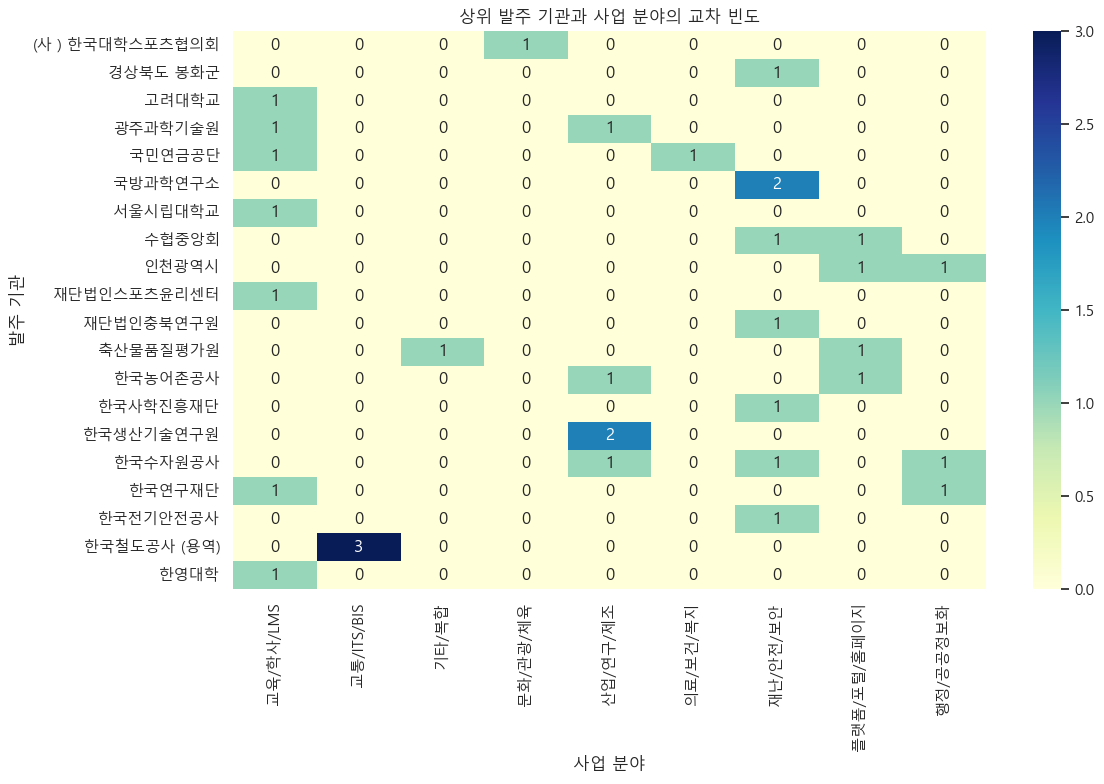


**RAG 시사점**

- 특정 기관이 특정 분야에 집중되어 있다면, 질의에서 기관명이 들어온 순간 **분야 prior**를 줄 수 있습니다.
- 기관과 분야가 약하게 연결되어 있으면, 기관 필터만으로는 부족하고 **내용 기반 retrieval** 비중을 높여야 합니다.


In [11]:
# ============================================================
# 4-1. 발주 기관 x 사업 분야 교차 분석
# ============================================================
top_org_list = df["발주 기관"].value_counts().head(20).index.tolist()
heatmap_df = pd.crosstab(
    df.loc[df["발주 기관"].isin(top_org_list), "발주 기관"],
    df.loc[df["발주 기관"].isin(top_org_list), "사업 분야"],
)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_df, annot=True, fmt="d", cmap="YlGnBu")
plt.title("상위 발주 기관과 사업 분야의 교차 빈도")
plt.xlabel("사업 분야")
plt.ylabel("발주 기관")
plt.tight_layout()
plt.show()

display(Markdown('''
**RAG 시사점**

- 특정 기관이 특정 분야에 집중되어 있다면, 질의에서 기관명이 들어온 순간 **분야 prior**를 줄 수 있습니다.
- 기관과 분야가 약하게 연결되어 있으면, 기관 필터만으로는 부족하고 **내용 기반 retrieval** 비중을 높여야 합니다.
'''))


In [12]:
# ============================================================
# 4-2. 예산 규모와 문서 길이 상관관계
# ============================================================
corr_df = df.dropna(subset=["사업 금액", "char_count"]).copy()
pearson_corr = corr_df[["사업 금액", "char_count"]].corr(method="pearson").iloc[0, 1]
spearman_corr = corr_df[["사업 금액", "char_count"]].corr(method="spearman").iloc[0, 1]

fig = px.scatter(
    corr_df,
    x="사업 금액",
    y="char_count",
    color="사업 분야",
    size="word_count",
    hover_data=["사업명", "발주 기관", "파일형식"],
    title="예산 규모와 문서 길이의 관계",
    log_x=True,
)
fig.show()

display(Markdown(f'''
**상관계수**

- Pearson correlation: **{pearson_corr:.3f}**
- Spearman correlation: **{spearman_corr:.3f}**

**해석 가이드**

- Pearson은 선형 관계, Spearman은 순위 기반 관계를 봅니다.
- 비선형적이거나 극단값이 많은 예산 분포에서는 Spearman이 더 실무적으로 유용합니다.
'''))



**상관계수**

- Pearson correlation: **0.027**
- Spearman correlation: **0.016**

**해석 가이드**

- Pearson은 선형 관계, Spearman은 순위 기반 관계를 봅니다.
- 비선형적이거나 극단값이 많은 예산 분포에서는 Spearman이 더 실무적으로 유용합니다.


In [13]:
# ============================================================
# 4-3. 메타데이터 유사도 패턴 탐색 (기관명 / 사업명)
# ============================================================
def top_similar_pairs(values, analyzer="char_wb", ngram_range=(2, 4), min_sim=0.35, top_n=20):
    values = pd.Series(values).dropna().astype(str).str.strip()
    values = values[values != ""].drop_duplicates().reset_index(drop=True)
    if len(values) < 2:
        return pd.DataFrame(columns=["left", "right", "similarity"])

    vec = TfidfVectorizer(analyzer=analyzer, ngram_range=ngram_range)
    mat = vec.fit_transform(values)
    sim = cosine_similarity(mat)

    pairs = []
    for i in range(len(values)):
        for j in range(i + 1, len(values)):
            if sim[i, j] >= min_sim:
                pairs.append((values[i], values[j], float(sim[i, j])))
    out = pd.DataFrame(pairs, columns=["left", "right", "similarity"])
    if out.empty:
        return out
    return out.sort_values("similarity", ascending=False).head(top_n)

org_similar = top_similar_pairs(df["발주 기관"], min_sim=0.30, top_n=20)
title_similar = top_similar_pairs(df["사업명"], min_sim=0.25, top_n=20)

display(Markdown("### 기관명 유사 쌍 Top 20"))
display(org_similar)

display(Markdown("### 사업명 유사 쌍 Top 20"))
display(title_similar)

normalized_org_groups = (
    df.groupby("발주기관_정규화")["발주 기관"]
    .agg(lambda x: sorted(set(x)))
    .reset_index()
)
normalized_org_groups["표현수"] = normalized_org_groups["발주 기관"].apply(len)
alias_candidates = normalized_org_groups[normalized_org_groups["표현수"] > 1].sort_values("표현수", ascending=False)

display(Markdown("### 정규화 기준 Alias 후보"))
display(alias_candidates.head(20))

if not org_similar.empty:
    fig = px.histogram(org_similar, x="similarity", nbins=15, title="기관명 유사도 분포 (상위 유사 쌍)")
    fig.show()

display(Markdown('''
**RAG 시사점**

- 기관명/사업명은 사용자가 정확히 입력하지 않을 수 있으므로, 실제 서비스에서는 **정규화 + fuzzy retrieval** 조합이 필요합니다.
- Alias 후보는 metadata filter 단계의 사전(dictionary) 또는 query rewrite 규칙으로 재사용할 수 있습니다.
- 사업명 유사도가 높다고 동일 사업은 아니므로, 최종 필터링은 텍스트 기반 근거와 함께 사용해야 합니다.
'''))


### 기관명 유사 쌍 Top 20

,left,right,similarity
0,인천광역시,인천광역시 동구,0.802453
7,서울특별시,서울특별시 여성가족재단,0.622857
8,서울특별시,서울특별시교육청,0.575296
10,경기도 평택시,경기도 안양시,0.456743
12,재단법인 광주연구원,재단법인 광주광역시 광주문화재단,0.433400
4,한국보건산업진흥원,한국로봇산업진흥원,0.420600
3,한국수자원공사,한국수자원조사기술원,0.417213
2,재단법인충북연구원,재단법인 광주연구원,0.402519
13,한국산업인력공단,한국산업단지공단,0.368762
11,서울특별시 여성가족재단,서울특별시교육청,0.358327


### 사업명 유사 쌍 Top 20

,left,right,similarity
1,의료기기산업 종합정보시스템(정보관리기관) 기능개선 사업,의료기기산업 종합정보시스템(정보관리기관) 기능개선 사업(2차),0.883089
3,2024년 버스정보시스템 확대 구축 및 기능개선 용역,2024년도 평택시 버스정보시스템(BIS) 구축사업,0.386627
9,철도인프라 디지털트윈 정보화전략계획(ISP) 수립 용역(변경공고),서울특별시교육청 지능정보화전략계획(ISP) 수립(2차) 사업 용역,0.365980
0,통합정보시스템 고도화 용역,[재공고]차세대 통합정보시스템(ERP) 구축,0.337198
6,학사시스템 기능개선 사업,꿀 품질평가 전산시스템 기능개선 사업,0.334377
5,경영정보시스템 기능개선,학사시스템 기능개선 사업,0.326328
2,2024년 버스정보시스템 확대 구축 및 기능개선 용역,경영정보시스템 기능개선,0.315719
7,2025년 통합접수시스템 운영,2025년 아이돌봄인력 인적성 검사 정보시스템 운영,0.306637
8,2024년 이러닝시스템 운영 용역,2024년 장애인문화예술정보시스템 이음온라인 운영 용역,0.304472
4,e나라도움 업무시스템 웹 접근성 컨설팅,통합 정보시스템 구축 사전 컨설팅,0.275830


### 정규화 기준 Alias 후보

,발주기관_정규화,발주 기관,표현수



**RAG 시사점**

- 기관명/사업명은 사용자가 정확히 입력하지 않을 수 있으므로, 실제 서비스에서는 **정규화 + fuzzy retrieval** 조합이 필요합니다.
- Alias 후보는 metadata filter 단계의 사전(dictionary) 또는 query rewrite 규칙으로 재사용할 수 있습니다.
- 사업명 유사도가 높다고 동일 사업은 아니므로, 최종 필터링은 텍스트 기반 근거와 함께 사용해야 합니다.


## 5. 텍스트 키워드 및 내용 분석 (Text Content Analysis)

### 이 단계에서 확인할 것

- 전체 문서를 관통하는 핵심 키워드는 무엇인가?
- 사업 분야별로 어떤 표현이 특징적인가?
- 문서 간 의미적 군집이 자연스럽게 형성되는가?

### RAG 설계 관점 인사이트

- 분야별 특징 키워드는 metadata tag 자동 생성이나 query expansion 후보가 됩니다.
- 군집 구조가 뚜렷하면, retrieval 전에 **coarse routing**을 둘 수 있습니다.
- 반대로 군집이 약하면, 사업 분야는 정교한 분류 모델보다 **보조 메타데이터** 수준으로 다루는 것이 안전합니다.


In [14]:
# ============================================================
# 5-1. TF-IDF 기반 키워드 추출
# ============================================================
STOPWORDS = {
    "사업", "시스템", "구축", "용역", "기능", "고도화", "운영", "개발", "관리", "정보", "지원",
    "관련", "제안", "요청", "내용", "추진", "통해", "위한", "대상", "수행", "이용", "구성",
    "개선", "기반", "필요", "사항", "업무", "제출", "평가", "계약", "기관", "활용", "제공",
    "사업명", "사업비", "기간", "범위", "시스템구축", "고도화사업", "요구사항", "구축사업",
    "통합", "기능개선", "운영지원", "사업개요", "추진방안", "제안요청서", "입찰", "계약일",
}

def token_for_tfidf(text: str):
    tokens = re.findall(r"[가-힣A-Za-z0-9]+", str(text).lower())
    tokens = [t for t in tokens if len(t) >= 2 and t not in STOPWORDS]
    return tokens

df["tfidf_text"] = (
    df["사업명"].fillna("") + " " +
    df["사업 요약"].fillna("") + " " +
    df["정제텍스트"].fillna("")
)

vectorizer = TfidfVectorizer(
    tokenizer=token_for_tfidf,
    token_pattern=None,
    min_df=2,
    max_df=0.85,
    max_features=3000,
    ngram_range=(1, 2),
)
tfidf_matrix = vectorizer.fit_transform(df["tfidf_text"])
feature_names = np.array(vectorizer.get_feature_names_out())

overall_scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
top_idx = overall_scores.argsort()[::-1][:25]
overall_keywords = pd.DataFrame({
    "keyword": feature_names[top_idx],
    "mean_tfidf": overall_scores[top_idx],
})
display(overall_keywords)

fig = px.bar(
    overall_keywords.head(20),
    x="mean_tfidf",
    y="keyword",
    orientation="h",
    title="전체 문서 기준 상위 TF-IDF 키워드",
    text="mean_tfidf",
)
fig.update_layout(height=600, yaxis=dict(categoryorder="total ascending"))
fig.show()

field_keyword_rows = []
for field in df["사업 분야"].value_counts().head(6).index:
    idx = df.index[df["사업 분야"] == field].tolist()
    if len(idx) < 2:
        continue
    field_scores = np.asarray(tfidf_matrix[idx].mean(axis=0)).ravel()
    field_top_idx = field_scores.argsort()[::-1][:10]
    for rank, i in enumerate(field_top_idx, start=1):
        field_keyword_rows.append(
            {
                "사업 분야": field,
                "rank": rank,
                "keyword": feature_names[i],
                "score": field_scores[i],
            }
        )

field_keywords_df = pd.DataFrame(field_keyword_rows)
display(field_keywords_df.head(60))

fig = px.bar(
    field_keywords_df,
    x="score",
    y="keyword",
    color="사업 분야",
    facet_col="사업 분야",
    facet_col_wrap=2,
    orientation="h",
    title="사업 분야별 대표 키워드 (TF-IDF)",
    height=900,
)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.show()

display(Markdown('''
**RAG 시사점**

- 상위 키워드는 retrieval query expansion, 사용자 질의 의도 분류, metadata tag 자동 생성의 후보입니다.
- 분야별 키워드가 명확하게 갈리면, coarse retrieval 단계에서 **분야별 인덱스 분리**를 실험할 수 있습니다.
- 반대로 공통 키워드가 과도하게 많으면 불용어 사전과 normalization 규칙을 더 강화해야 합니다.
'''))


,keyword,mean_tfidf
0,제안서,0.064766
1,서식,0.046195
2,데이터,0.037142
3,현황,0.034580
4,대한,0.029687
5,별지,0.028042
6,붙임,0.027962
7,서비스,0.027207
8,분석,0.026194
9,추진배경,0.025825


,사업 분야,rank,keyword,score
0,재난/안전/보안,1,제안서,0.077694
1,재난/안전/보안,2,한다,0.055769
2,재난/안전/보안,3,데이터,0.051425
3,재난/안전/보안,4,서식,0.046554
4,재난/안전/보안,5,requirement,0.044289
5,재난/안전/보안,6,별지,0.042052
6,재난/안전/보안,7,환경,0.038939
7,재난/안전/보안,8,재난안전데이터,0.038027
8,재난/안전/보안,9,분석,0.036650
9,재난/안전/보안,10,사후관리,0.036328



**RAG 시사점**

- 상위 키워드는 retrieval query expansion, 사용자 질의 의도 분류, metadata tag 자동 생성의 후보입니다.
- 분야별 키워드가 명확하게 갈리면, coarse retrieval 단계에서 **분야별 인덱스 분리**를 실험할 수 있습니다.
- 반대로 공통 키워드가 과도하게 많으면 불용어 사전과 normalization 규칙을 더 강화해야 합니다.


,k,silhouette
0,2,0.013336
1,3,0.013823
2,4,0.015536
3,5,0.015250
4,6,0.014186
5,7,0.015113
6,8,0.018608


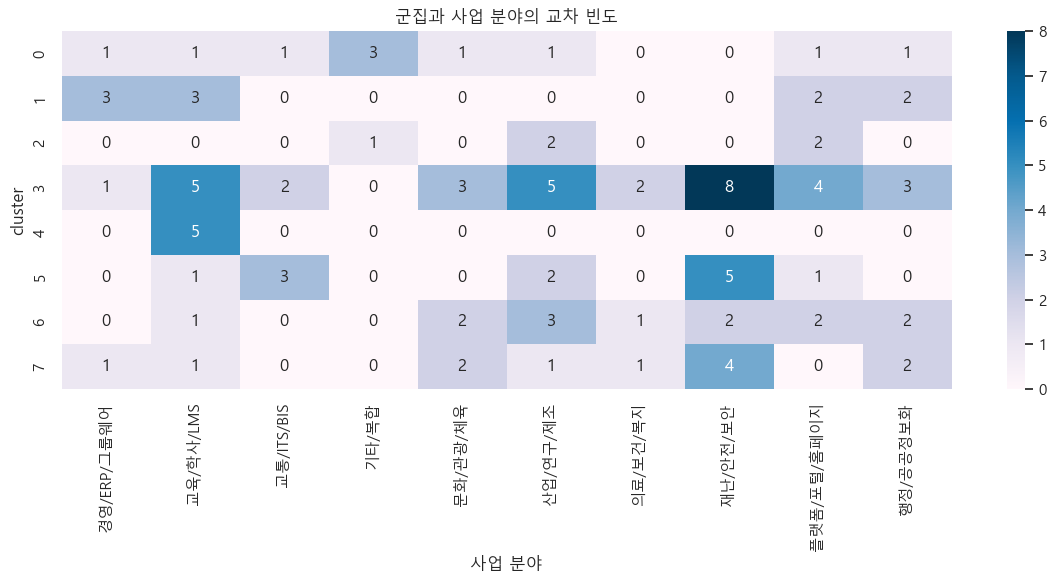


**군집 해석 포인트**

- 최적 k(실루엣 기준): **8**
- 군집이 사업 분야와 대체로 일치하면, retrieval 전에 **routing / candidate narrowing**을 적용할 여지가 있습니다.
- 군집이 섞여 있다면, 사업 분야는 강한 hard label이 아니라 **soft prior**로 보는 편이 적절합니다.


In [15]:
# ============================================================
# 5-2. 문서 군집화 가능성 탐색
# ============================================================
k_range = range(2, 9)
silhouette_scores = []

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(tfidf_matrix)
    score = silhouette_score(tfidf_matrix, labels)
    silhouette_scores.append({"k": k, "silhouette": score})

silhouette_df = pd.DataFrame(silhouette_scores)
display(silhouette_df)

fig = px.line(
    silhouette_df,
    x="k",
    y="silhouette",
    markers=True,
    title="군집 수(k)별 Silhouette Score",
)
fig.show()

best_k = int(silhouette_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
df["cluster"] = kmeans.fit_predict(tfidf_matrix)

svd = TruncatedSVD(n_components=2, random_state=42)
coords = svd.fit_transform(tfidf_matrix)
plot_df = df[["사업명", "발주 기관", "사업 분야", "cluster"]].copy()
plot_df["x"] = coords[:, 0]
plot_df["y"] = coords[:, 1]

fig = px.scatter(
    plot_df,
    x="x",
    y="y",
    color=plot_df["cluster"].astype(str),
    symbol="사업 분야",
    hover_data=["사업명", "발주 기관"],
    title=f"TF-IDF 기반 문서 군집화 시각화 (best k = {best_k})",
    height=700,
)
fig.show()

cluster_field = pd.crosstab(df["cluster"], df["사업 분야"])
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_field, annot=True, fmt="d", cmap="PuBu")
plt.title("군집과 사업 분야의 교차 빈도")
plt.xlabel("사업 분야")
plt.ylabel("cluster")
plt.tight_layout()
plt.show()

display(Markdown(f'''
**군집 해석 포인트**

- 최적 k(실루엣 기준): **{best_k}**
- 군집이 사업 분야와 대체로 일치하면, retrieval 전에 **routing / candidate narrowing**을 적용할 여지가 있습니다.
- 군집이 섞여 있다면, 사업 분야는 강한 hard label이 아니라 **soft prior**로 보는 편이 적절합니다.
'''))


## 6. RAG 파이프라인 설계를 위한 실행 가능한 시사점 정리

마지막으로, 앞선 분석 결과를 바탕으로 **chunking / metadata filtering / 데이터 품질 관리** 관점의 액션 아이템을 정리합니다.


In [16]:
# ============================================================
# 6. 액션 아이템 요약
# ============================================================
char_q50 = df["char_count"].median()
char_q75 = df["char_count"].quantile(0.75)
short_doc_count = int((df["char_count"] < 500).sum())
medium_section = float(section_summary_df["mean_section_chars"].dropna().median()) if section_summary_df["mean_section_chars"].notna().any() else np.nan

if np.isnan(medium_section):
    recommended_chunk = int(np.clip(char_q50 * 0.2, 500, 1200))
else:
    recommended_chunk = int(np.clip(medium_section * 0.8, 500, 1200))
recommended_overlap = int(np.clip(recommended_chunk * 0.15, 80, 220))

retrieval_filters = [
    "발주 기관",
    "사업 분야(휴리스틱)",
    "공개연도",
    "예산 구간",
    "파일형식",
]

normalized_org_groups = (
    df.groupby("발주기관_정규화")["발주 기관"]
    .agg(lambda x: sorted(set(x)))
    .reset_index()
)
normalized_org_groups["표현수"] = normalized_org_groups["발주 기관"].apply(len)

display(Markdown(f'''
### 데이터 기반 추천안

**1. Chunking baseline 후보**

- 추천 baseline chunk size: **약 {recommended_chunk}자**
- 추천 baseline overlap: **약 {recommended_overlap}자**
- 이유:
  - 문서 글자 수 중앙값: **{char_q50:,.0f}자**
  - 문서 글자 수 75% 지점: **{char_q75:,.0f}자**
  - 추정 평균 섹션 길이 중앙값: **{medium_section:,.0f}자**

**2. 우선 적용할 metadata filter 후보**

- {', '.join(retrieval_filters)}

**3. 품질 점검 우선순위**

- 글자 수 500자 미만 문서: **{short_doc_count}건**
- 금액 0 또는 결측 문서: **{int(((df['사업 금액'].fillna(0) <= 0)).sum())}건**
- 정규화 후 기관명 alias 후보: **{int((normalized_org_groups['표현수'] > 1).sum())}개 그룹**

**4. 다음 실험 권장 순서**

1. fixed-size chunk baseline ({recommended_chunk}/{recommended_overlap}) 구축
2. `발주 기관 + 사업 분야 + 예산 구간` 메타데이터 필터링 실험
3. 짧은 문서 재파싱 및 품질 보정
4. section-aware chunking 실험
5. 분야별/기관별 평가셋 분리 평가
'''))

review_candidates = df[(df["char_count"] < 500) | (df["사업 금액"].fillna(0) <= 0)].copy()
review_candidates = review_candidates.sort_values(["char_count", "사업 금액"], ascending=[True, True])
display(Markdown("### 재검토 우선 문서 목록"))
display(review_candidates[["사업명", "발주 기관", "사업 금액", "char_count", "파일형식", "파일명"]].head(30))



### 데이터 기반 추천안

**1. Chunking baseline 후보**

- 추천 baseline chunk size: **약 500자**
- 추천 baseline overlap: **약 80자**
- 이유:
  - 문서 글자 수 중앙값: **2,264자**
  - 문서 글자 수 75% 지점: **5,073자**
  - 추정 평균 섹션 길이 중앙값: **552자**

**2. 우선 적용할 metadata filter 후보**

- 발주 기관, 사업 분야(휴리스틱), 공개연도, 예산 구간, 파일형식

**3. 품질 점검 우선순위**

- 글자 수 500자 미만 문서: **15건**
- 금액 0 또는 결측 문서: **7건**
- 정규화 후 기관명 alias 후보: **0개 그룹**

**4. 다음 실험 권장 순서**

1. fixed-size chunk baseline (500/80) 구축
2. `발주 기관 + 사업 분야 + 예산 구간` 메타데이터 필터링 실험
3. 짧은 문서 재파싱 및 품질 보정
4. section-aware chunking 실험
5. 분야별/기관별 평가셋 분리 평가


### 재검토 우선 문서 목록

,사업명,발주 기관,사업 금액,char_count,파일형식,파일명
18,2024년 건설기술에 관한 특허·실용신안 활용실적 관리시스템 개편 용역,한국발명진흥회 입찰공고,87000000.0,66,hwp,한국발명진흥회 입찰공고_2024년 건설기술에 관한 특허·실용신안 활용실.hwp
20,JST 공유대학(원) xAPI기반 LRS시스템 구축,전북대학교,116000000.0,94,hwp,전북대학교_JST 공유대학(원) xAPI기반 LRS시스템 구축.hwp
17,2025 구미아시아육상경기선수권대회 종합정보시스템 및 홈페이지 등 구축 용역,2025 구미 아시아육상경기선수권대회 조직위원회,260000000.0,150,hwp,2025 구미 아시아육상경기선수권대회 조직위원회_2025 구미아시아육상경.hwp
12,[사전공개] 학업성취도 다차원 종단분석 통합시스템 1차 고도화 용역,서울시립대학교,0.0,179,pdf,서울시립대학교_[사전공개] 학업성취도 다차원 종단분석 통합시스템 1차.pdf
2,EIP3.0 고압가스 안전관리 시스템 구축 용역,한국생산기술연구원,40000000.0,182,hwp,한국생산기술연구원_EIP3.0 고압가스 안전관리 시스템 구축 용역.hwp
8,스포츠윤리센터 LMS(학습지원시스템) 기능개선,재단법인스포츠윤리센터,46445000.0,205,hwp,재단법인스포츠윤리센터_스포츠윤리센터 LMS(학습지원시스템) 기능개선.hwp
49,사업장 사회보험료 지원 고시 개정에 따른 정보시스템 보완 개발,국민연금공단,415977877.0,340,hwp,국민연금공단_사업장 사회보험료 지원 고시 개정에 따른 정보시스템 보.hwp
86,2024년 벤처확인종합관리시스템 기능 고도화 용역사업 입찰공고,(사)벤처기업협회,352000000.0,398,hwp,(사)벤처기업협회_2024년 벤처확인종합관리시스템 기능 고도화 용역사업 .hwp
78,IP-NAVI 해외지식재산센터 사업관리 시스템 기능개선,한국지식재산보호원,60000000.0,411,hwp,한국지식재산보호원_IP-NAVI 해외지식재산센터 사업관리 시스템 기능개.hwp
53,통합정보시스템 고도화 용역,한국한의학연구원,140000000.0,421,hwp,한국한의학연구원_통합정보시스템 고도화 용역.hwp
